In [ ]:
#Check whether GPU  is available
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install tensorflow kaggle matplotlib numpy pillow -q

In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)

# Paste your NEW token here after revoking the exposed one
kaggle_token = "KGAT_d524182bcd98ae9205bee4cdbce09645"

# Write it in the new format
with open('/root/.kaggle/access_token', 'w') as f:
    f.write(kaggle_token)

os.chmod('/root/.kaggle/access_token', 0o600)

# Also set as environment variable
os.environ['KAGGLE_TOKEN'] = kaggle_token

print("Done")

Done


In [ ]:
!pip install kaggle -q
!kaggle datasets download -d iqrapervez2000/lettuce-disease-dataset
!unzip -q lettuce-disease-dataset.zip -d /content/lettuce_dataset
print("Dataset ready")

Dataset URL: https://www.kaggle.com/datasets/iqrapervez2000/lettuce-disease-dataset
License(s): unknown
100% 3.54G/3.54G [00:44<00:00, 85.8MB/s]

Dataset ready


In [ ]:
import os

for root, dirs, files in os.walk('/content/lettuce_dataset'):
    level = root.replace('/content/lettuce_dataset', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for file in files[:3]:
            print(f'{subindent}{file}')
        if len(files) > 3:
            print(f'{subindent}... and {len(files)-3} more files')

lettuce_dataset/
  Diseases/
    Lettuce_disease_datasets/
      Healthy/
    Diseases/
      Lettuce_disease_datasets/
        Healthy/
        Pest damage/
        Shepherd_purse_weeds/
        Fungal/
        Bacterial/
    archive/
      Lettuce_disease_datasets/
        Healthy/
        Downy_mildew_on_lettuce/
        Shepherd_purse_weeds/
        Wilt_and_leaf_blight_on_lettuce/
        Viral/
        Powdery_mildew_on_lettuce/
        Bacterial/
        Septoria_blight_on_lettuce/


In [ ]:
import os

# Check image counts in both versions
print("=== VERSION 1 (Diseases/Diseases/Lettuce_disease_datasets) ===")
base1 = '/content/lettuce_dataset/Diseases/Diseases/Lettuce_disease_datasets'
for category in os.listdir(base1):
    path = os.path.join(base1, category)
    if os.path.isdir(path):
        count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"  {category}: {count} images")

print("\n=== VERSION 2 (Diseases/archive/Lettuce_disease_datasets) ===")
base2 = '/content/lettuce_dataset/Diseases/archive/Lettuce_disease_datasets'
for category in os.listdir(base2):
    path = os.path.join(base2, category)
    if os.path.isdir(path):
        count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"  {category}: {count} images")

=== VERSION 1 (Diseases/Diseases/Lettuce_disease_datasets) ===
  Healthy: 1123 images
  Pest damage: 513 images
  Shepherd_purse_weeds: 1106 images
  Fungal: 581 images
  Bacterial: 729 images

=== VERSION 2 (Diseases/archive/Lettuce_disease_datasets) ===
  Healthy: 1123 images
  Downy_mildew_on_lettuce: 30 images
  Shepherd_purse_weeds: 1106 images
  Wilt_and_leaf_blight_on_lettuce: 6 images
  Viral: 15 images
  Powdery_mildew_on_lettuce: 18 images
  Bacterial: 20 images
  Septoria_blight_on_lettuce: 19 images


In [ ]:
# ── DATASET LEGITIMACY CHECK (Version 1) ──────────────────
# Checks: duplicates, near-duplicates, image dimensions/consistency,
# corrupt files, and basic visual sanity (random sample preview).

import os
import hashlib
from pathlib import Path
from collections import defaultdict

!pip install imagehash --quiet
from PIL import Image
import imagehash

BASE = '/content/lettuce_dataset/Diseases/Diseases/Lettuce_disease_datasets'
CLASSES = ['Pest damage', 'Shepherd_purse_weeds', 'Fungal', 'Healthy', 'Bacterial']

image_extensions = ('.jpg', '.jpeg', '.png')

exact_hashes = defaultdict(list)
perceptual_hashes = defaultdict(list)
class_counts = {}
dimensions = defaultdict(list)
corrupt_files = []
total_images = 0

print("Scanning Version 1 dataset...\n")

for cls in CLASSES:
    class_path = os.path.join(BASE, cls)
    if not os.path.isdir(class_path):
        print(f"⚠️  Folder not found: {class_path}")
        continue

    files = [f for f in os.listdir(class_path) if f.lower().endswith(image_extensions)]
    class_counts[cls] = len(files)
    total_images += len(files)

    for fname in files:
        fpath = os.path.join(class_path, fname)

        # Exact duplicate check (MD5 of file bytes)
        try:
            with open(fpath, 'rb') as f:
                h = hashlib.md5(f.read()).hexdigest()
            exact_hashes[h].append(fpath)
        except Exception as e:
            corrupt_files.append((fpath, str(e)))
            continue

        # Perceptual hash + dimension check
        try:
            img = Image.open(fpath)
            img.verify()  # checks file isn't truncated/corrupt
            img = Image.open(fpath)  # reopen after verify (verify closes it)
            dimensions[cls].append(img.size)
            phash = str(imagehash.average_hash(img))
            perceptual_hashes[phash].append(fpath)
        except Exception as e:
            corrupt_files.append((fpath, str(e)))

# ── REPORT ──────────────────────────────────────────────
print("=" * 60)
print("CLASS BALANCE")
print("=" * 60)
for cls, count in class_counts.items():
    pct = (count / total_images * 100) if total_images else 0
    print(f"  {cls:<25} {count:>5} images ({pct:5.1f}%)")
print(f"\n  Total: {total_images} images")
if class_counts:
    ratio = max(class_counts.values()) / min(class_counts.values())
    print(f"  Largest/smallest class ratio: {ratio:.2f}x")

print("\n" + "=" * 60)
print("EXACT DUPLICATES")
print("=" * 60)
exact_dupes = {h: p for h, p in exact_hashes.items() if len(p) > 1}
if exact_dupes:
    total_dupe_files = sum(len(p) for p in exact_dupes.values())
    redundant = sum(len(p) - 1 for p in exact_dupes.values())
    print(f"  ⚠️  {len(exact_dupes)} duplicate groups, {total_dupe_files} files involved, {redundant} redundant copies")
    print(f"  ({redundant} fewer truly unique images than the raw count suggests)")
else:
    print("  ✅ No exact duplicates")

print("\n" + "=" * 60)
print("NEAR-DUPLICATES (visually near-identical)")
print("=" * 60)
near_dupes = {h: p for h, p in perceptual_hashes.items() if len(p) > 1}
if near_dupes:
    total_near = sum(len(p) for p in near_dupes.values())
    print(f"  ⚠️  {len(near_dupes)} groups, {total_near} files flagged as visually near-identical")
    print("  (could be legitimate augmentation, or could be inflated duplicates - worth a manual peek)")
else:
    print("  ✅ No near-duplicates detected")

print("\n" + "=" * 60)
print("IMAGE DIMENSIONS (consistency check)")
print("=" * 60)
for cls, dims in dimensions.items():
    unique_dims = set(dims)
    print(f"  {cls}: {len(unique_dims)} distinct resolution(s) across {len(dims)} images")
    if len(unique_dims) <= 5:
        for d in unique_dims:
            count = dims.count(d)
            print(f"      {d[0]}x{d[1]}  -> {count} images")

print("\n" + "=" * 60)
print("CORRUPT / UNREADABLE FILES")
print("=" * 60)
if corrupt_files:
    print(f"  ⚠️  {len(corrupt_files)} problem files:")
    for p, reason in corrupt_files[:10]:
        print(f"    {p} — {reason}")
else:
    print("  ✅ All files opened successfully")

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"  Total images scanned:     {total_images}")
print(f"  Exact duplicate copies:   {sum(len(p)-1 for p in exact_dupes.values()) if exact_dupes else 0}")
print(f"  Near-duplicate groups:    {len(near_dupes)}")
print(f"  Corrupt files:            {len(corrupt_files)}")
print(f"  Class imbalance ratio:    {ratio:.2f}x" if class_counts else "")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 6.6 MB/s eta 0:00:00
Scanning Version 1 dataset...

CLASS BALANCE
  Pest damage                 513 images ( 12.7%)
  Shepherd_purse_weeds       1106 images ( 27.3%)
  Fungal                      581 images ( 14.3%)
  Healthy                    1123 images ( 27.7%)
  Bacterial                   729 images ( 18.0%)

  Total: 4052 images
  Largest/smallest class ratio: 2.19x

EXACT DUPLICATES
  ⚠️  182 duplicate groups, 443 files involved, 261 redundant copies
  (261 fewer truly unique images than the raw count suggests)

NEAR-DUPLICATES (visually near-identical)
  ⚠️  254 groups, 684 files flagged as visually near-identical
  (could be legitimate augmentation, or could be inflated duplicates - worth a manual peek)

IMAGE DIMENSIONS (consistency check)
  Pest damage: 7 distinct resolution(s) across 513 images
  Shepherd_purse_weeds: 989 distinct resolution(s) across 1106 images
  Fungal: 108 distinct resolution(s) across 581 imag

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import os

# ── CONFIG ──────────────────────────────────────────────
BASE_DIR = '/content/lettuce_dataset/Diseases/Diseases/Lettuce_disease_datasets'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15
NUM_CLASSES = 5
# ────────────────────────────────────────────────────────

# ── DATA AUGMENTATION & LOADING ─────────────────────────
# Training data: augment to artificially increase variety
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,      # 80% train, 20% validation
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2
)

# Validation data: only rescale, no augmentation
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("\nClass labels:")
for label, index in train_generator.class_indices.items():
    print(f"  {index}: {label}")

print(f"\nTraining images: {train_generator.samples}")
print(f"Validation images: {val_generator.samples}")

Found 3244 images belonging to 5 classes.
Found 808 images belonging to 5 classes.

Class labels:
  0: Bacterial
  1: Fungal
  2: Healthy
  3: Pest damage
  4: Shepherd_purse_weeds

Training images: 3244
Validation images: 808


In [ ]:
# ── BUILD MODEL ─────────────────────────────────────────
# Load MobileNetV2 pretrained on ImageNet, without top layer
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,          # remove ImageNet's 1000-class layer
    weights='imagenet'          # use pretrained weights
)

# Freeze base model (don't touch pretrained weights yet)
base_model.trainable = False

# Build your new top (classification head)
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)       # flatten feature map
x = Dropout(0.3)(x)                   # prevent overfitting
outputs = Dense(NUM_CLASSES, activation='softmax')(x)  # 5 output classes

model = Model(inputs, outputs)

# ── COMPILE ─────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ── CALLBACKS ───────────────────────────────────────────
callbacks = [
    # Save best model automatically
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/lettuce_model_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # Stop early if no improvement after 5 epochs
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate if stuck
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

# ── TRAIN PHASE 1: train only the new top layer ─────────
print("Phase 1: Training classification head only...")
history1 = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

Phase 1: Training classification head only...
Epoch 1/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 955ms/step - accuracy: 0.6566 - loss: 0.9658
Epoch 1: val_accuracy improved from None to 0.89851, saving model to /content/drive/MyDrive/lettuce_model_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/lettuce_model_best.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.7876 - loss: 0.5883 - val_accuracy: 0.8985 - val_loss: 0.2836 - learning_rate: 0.0010
Epoch 2/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 840ms/step - accuracy: 0.8990 - loss: 0.2633
Epoch 2: val_accuracy improved from 0.89851 to 0.90718, saving model to /content/drive/MyDrive/lettuce_model_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/lettuce_model_best.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.9047 - loss: 0.2424 - val_accuracy: 0.9072 - val_loss: 0.2431 - learning_rate: 0.0010
Epoch 3/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 823ms/step - accuracy: 0.9215 - loss: 0.2003
Epo

In [ ]:
# ── PHASE 2: Unfreeze top layers of base model ──────────
print("Phase 2: Fine-tuning top layers of MobileNetV2...")

# Unfreeze the base model
base_model.trainable = True

# But freeze everything except the last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with much lower learning rate
# (lower LR = careful fine-tuning, not destroying pretrained weights)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Count trainable vs frozen layers
trainable = sum([1 for l in model.layers if l.trainable])
print(f"Trainable layers: {trainable}")

# Train again with same callbacks
history2 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(
            '/content/drive/MyDrive/lettuce_model_best.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            verbose=1
        )
    ],
    verbose=1
)

print(f"\nBest val_accuracy after fine-tuning: {max(history2.history['val_accuracy']):.4f}")

Phase 2: Fine-tuning top layers of MobileNetV2...
Trainable layers: 5
Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 882ms/step - accuracy: 0.8027 - loss: 0.5317
Epoch 1: val_accuracy improved from None to 0.92327, saving model to /content/drive/MyDrive/lettuce_model_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/lettuce_model_best.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.8502 - loss: 0.4069 - val_accuracy: 0.9233 - val_loss: 0.2259 - learning_rate: 1.0000e-05
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 830ms/step - accuracy: 0.9075 - loss: 0.2267
Epoch 2: val_accuracy improved from 0.92327 to 0.92698, saving model to /content/drive/MyDrive/lettuce_model_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/lettuce_model_best.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 97s 954ms/step - accuracy: 0.9109 - loss: 0.2155 - val_accuracy: 0.9270 - val_loss: 0.2357 - learning_rate: 1.0000e-05
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 822ms/step - a

In [ ]:
# ── CONVERT TO TFLITE ────────────────────────────────────
import tensorflow as tf
import json

print("Converting to TFLite...")

# Load best saved model
model = tf.keras.models.load_model('/content/drive/MyDrive/lettuce_model_best.keras')

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # quantization — makes model smaller/faster on Pi
tflite_model = converter.convert()

# Save TFLite model to Drive
tflite_path = '/content/drive/MyDrive/lettuce_model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"✅ TFLite model saved: {tflite_path}")

# Check file size
size_mb = os.path.getsize(tflite_path) / (1024 * 1024)
print(f"Model size: {size_mb:.2f} MB")

# ── SAVE CLASS LABELS ────────────────────────────────────
# Save label mapping so Pi knows which index = which disease
labels = {v: k for k, v in train_generator.class_indices.items()}
labels_path = '/content/drive/MyDrive/lettuce_labels.json'
with open(labels_path, 'w') as f:
    json.dump(labels, f)

print(f"✅ Labels saved: {labels_path}")
print(f"Labels: {labels}")

Converting to TFLite...
Saved artifact at '/tmp/tmpuchi9msr'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  134491871624080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134491871621584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134491871621968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134491871621200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134491871623888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134491871623312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134491871616208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134491871621776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134491871623696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134491871622928: TensorSpec(shape=(), dtype=tf.resource, na

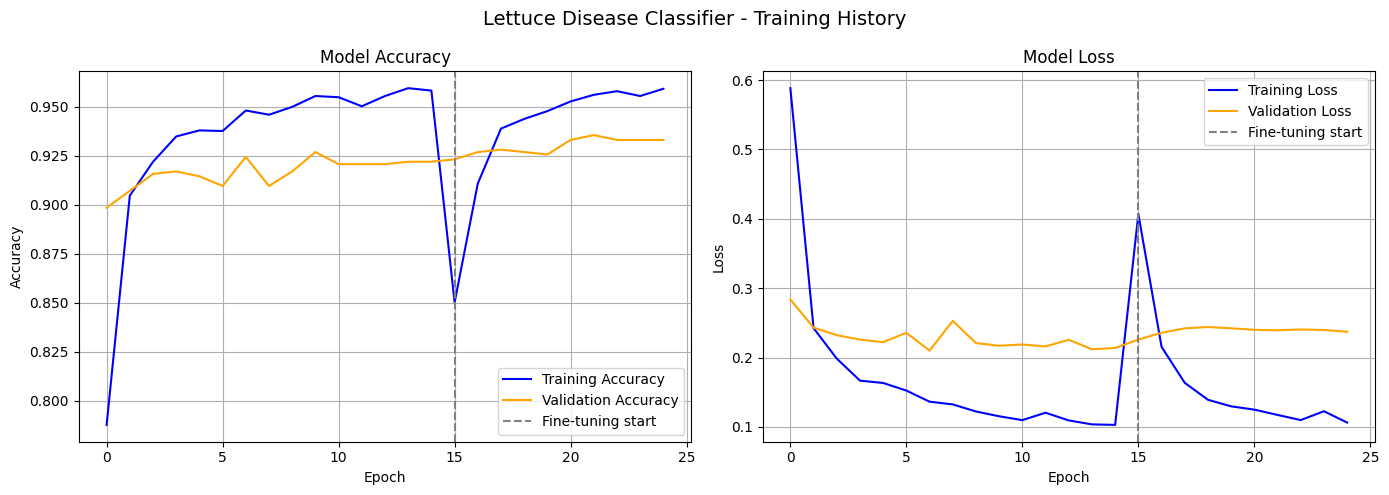

✅ Training graph saved to Drive


In [ ]:
# ── PLOT TRAINING HISTORY ────────────────────────────────
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Combine both phases
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']
epochs_range = range(len(acc))

# Phase divider
phase2_start = len(history1.history['accuracy'])

# Accuracy plot
ax1.plot(epochs_range, acc, label='Training Accuracy', color='blue')
ax1.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
ax1.axvline(x=phase2_start, color='gray', linestyle='--', label='Fine-tuning start')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(epochs_range, loss, label='Training Loss', color='blue')
ax2.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
ax2.axvline(x=phase2_start, color='gray', linestyle='--', label='Fine-tuning start')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('Lettuce Disease Classifier - Training History', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_history.png', dpi=150)
plt.show()
print("✅ Training graph saved to Drive")

In [ ]:
import shutil
import os

base = '/content/lettuce_dataset/Diseases/Diseases/Lettuce_disease_datasets'

for category in ['Healthy', 'Bacterial', 'Fungal']:
    # Get first image from each category
    folder = os.path.join(base, category)
    first_image = os.listdir(folder)[0]
    src = os.path.join(folder, first_image)
    dst = f'/content/drive/MyDrive/sample_{category.lower()}.jpg'
    shutil.copy(src, dst)
    print(f"Saved: sample_{category.lower()}.jpg")

Saved: sample_healthy.jpg
Saved: sample_bacterial.jpg
Saved: sample_fungal.jpg
